# 1. Data Understanding & Preparation

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV, StratifiedKFold,
    cross_val_predict, train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")

os.makedirs('images', exist_ok=True)

def save_fig(name):
    plt.savefig(f'images/{name}.png', dpi=300, bbox_inches='tight')

##Import & Display Raw Data

In [2]:
df = pd.read_csv('/content/aug_train.csv')

In [3]:
print("Shape:", df.shape)

Shape: (19158, 14)


In [4]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [6]:
print("\nMissing values per column:\n", df.isnull().sum().sort_values(ascending=False))


Missing values per column:
 company_type              6140
company_size              5938
gender                    4508
major_discipline          2813
education_level            460
last_new_job               423
enrolled_university        386
experience                  65
enrollee_id                  0
city                         0
relevent_experience          0
city_development_index       0
training_hours               0
target                       0
dtype: int64


##I. Missing value handling

In [7]:
df = df.drop(columns=['enrollee_id'], errors='ignore')

In [8]:
rows_before = len(df)
df = df.drop_duplicates()
print(f"\nRemoved {rows_before - len(df)} duplicate rows "
      f"(now {len(df)} rows)")


Removed 49 duplicate rows (now 19109 rows)


In [9]:
for col in ['company_size', 'company_type']:
    df[f'{col}_missing'] = df[col].isna().astype(int)

In [10]:
for col in ['gender', 'company_size', 'company_type', 'major_discipline']:
    df[col] = df[col].fillna('Unknown')

In [11]:
for col in ['education_level', 'enrolled_university', 'experience', 'last_new_job']:
    df[col] = df[col].fillna(df[col].mode()[0])

assert df.isnull().sum().sum() == 0, "There are still missing values!"
print("\n No missing values remain.")

df['target'] = df['target'].astype(int)


 No missing values remain.


## II. Feature engineering

Domain Knowledge & Mappings

In [12]:
df['experience'] = (
    df['experience'].replace({'>20': '21', '<1': '0'}).astype(float)
)

In [13]:
df['relevent_experience'] = df['relevent_experience'].map(
    {'Has relevent experience': 1, 'No relevent experience': 0}
).astype(int)

In [14]:
education_map = {'Primary School': 0, 'High School': 1, 'Graduate': 2, 'Masters': 3, 'Phd': 4}
df['education_level'] = df['education_level'].map(education_map)

In [15]:
size_map = {
    'Unknown': -1, '<10': 0, '10/49': 1, '50-99': 2, '100-500': 3,
    '500-999': 4, '1000-4999': 5, '5000-9999': 6, '10000+': 7,
}
df['company_size'] = df['company_size'].map(size_map)

In [16]:
last_job_map = {'never': 0, '1': 1, '2': 2, '3': 3, '4': 4, '>4': 5}
df['last_new_job'] = df['last_new_job'].map(last_job_map)

print("Feature Engineering completed successfully.")


Feature Engineering completed successfully.


## Data transformation

Scaling & Encoding

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [18]:
categorical_list = ['gender', 'enrolled_university', 'major_discipline', 'company_type']
numerical_list = [
    'relevent_experience', 'education_level', 'experience',
    'city_development_index', 'training_hours',
    'company_size', 'last_new_job',
    'company_size_missing', 'company_type_missing',
]

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_list),
        ('numerical', StandardScaler(), numerical_list),
    ]
)

In [20]:
X = df.drop(columns=['target', 'city'], errors='ignore')
y = df['target'].astype(int)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Data Transformation and Splitting completed successfully.")

Train shape: (15287, 13) | Test shape: (3822, 13)
Data Transformation and Splitting completed successfully.


# 2. EDA — Exploratory Data Analysis(Visualization)

## Target Distribution Analysis

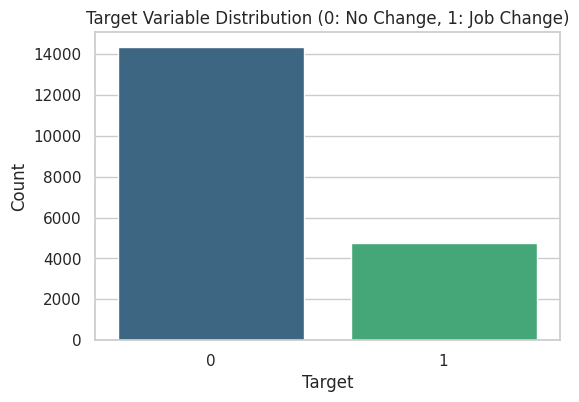

Class 0: 14344 (75.1%)
Class 1: 4765 (24.9%)


In [22]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', hue='target', palette='viridis', legend=False)
plt.title('Target Variable Distribution (0: No Change, 1: Job Change)')
plt.xlabel('Target')
plt.ylabel('Count')
save_fig('01_target_distribution')
plt.show()

print(f"Class 0: {(df['target']==0).sum()} ({(df['target']==0).mean()*100:.1f}%)")
print(f"Class 1: {(df['target']==1).sum()} ({(df['target']==1).mean()*100:.1f}%)")

## Education Level vs target

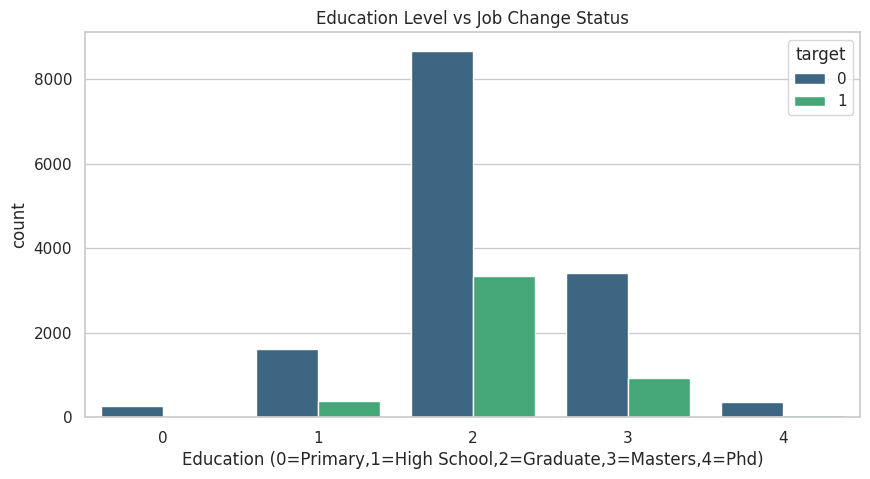

In [23]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='education_level', hue='target', palette='viridis')
plt.title('Education Level vs Job Change Status')
plt.xlabel('Education (0=Primary,1=High School,2=Graduate,3=Masters,4=Phd)')
plt.show()

## Experience vs target

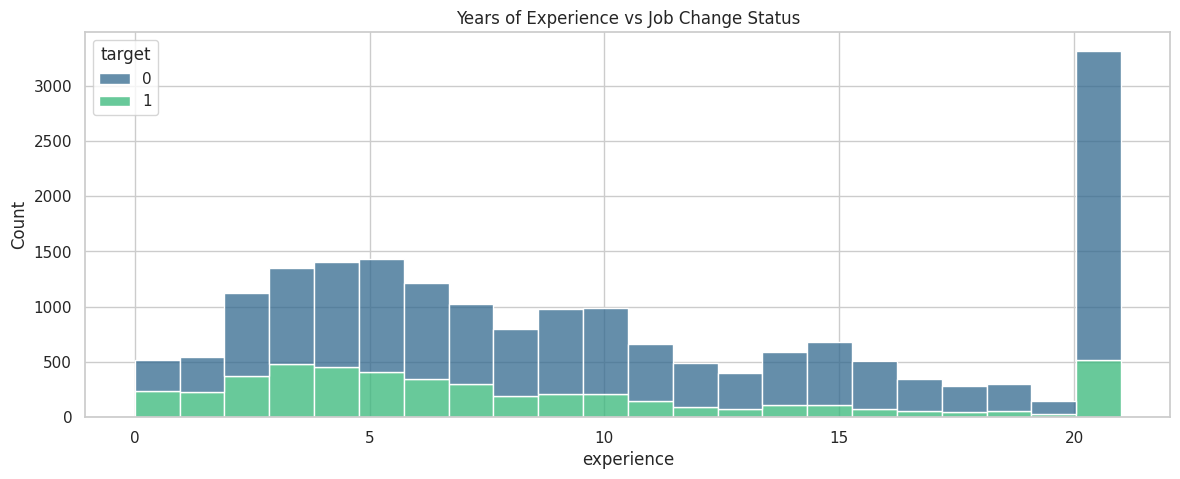

In [24]:
plt.figure(figsize=(14, 5))
sns.histplot(data=df, x='experience', hue='target', multiple='stack', bins=22, palette='viridis')
plt.title('Years of Experience vs Job Change Status')
plt.show()

## Training hours vs target

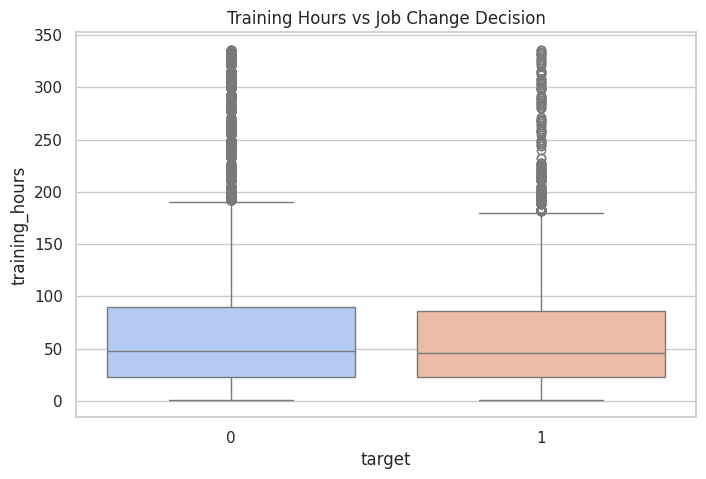

In [25]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='target', y='training_hours', hue='target', palette='coolwarm', legend=False)
plt.title('Training Hours vs Job Change Decision')
plt.show()

## City development index vs target

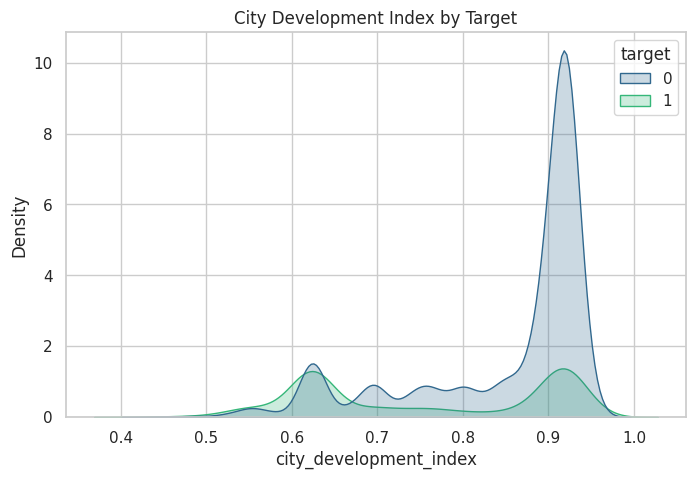

In [26]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='city_development_index', hue='target', fill=True, palette='viridis')
plt.title('City Development Index by Target')
plt.show()

## Correlation matrix (numeric features only)

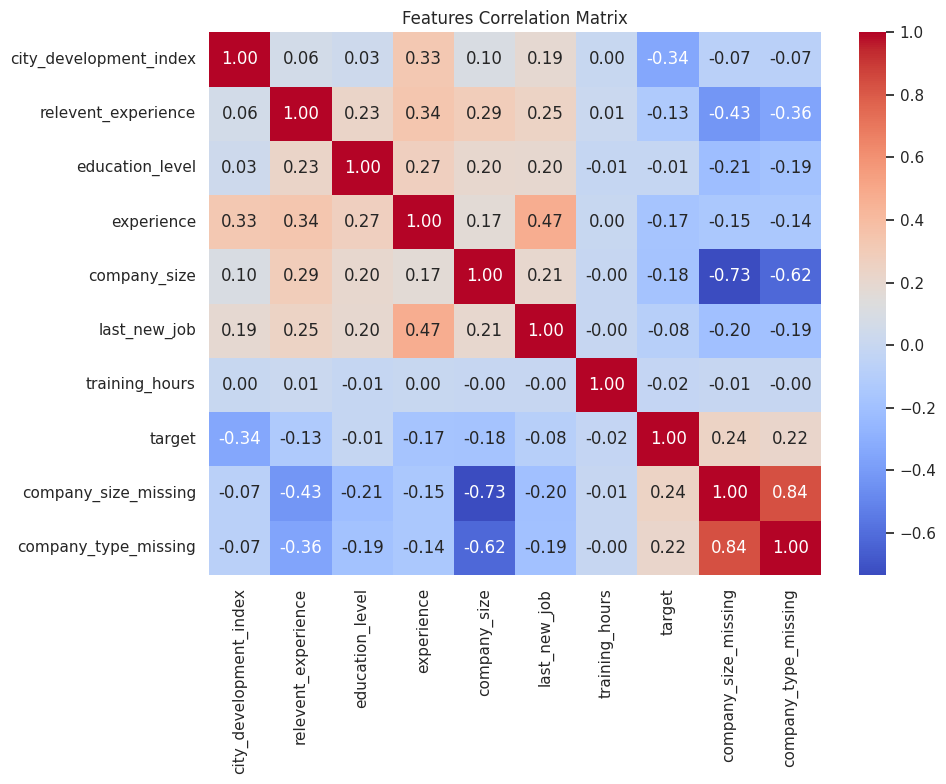

In [27]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Features Correlation Matrix')
plt.tight_layout()
save_fig('02_correlation_matrix')
plt.show()

# 3. Machine Learning Models

##Logistic Regression Model

In [28]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [29]:
lr_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', max_iter=3000, random_state=42)),
])

In [30]:
param_grid_lr = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__solver': ['lbfgs', 'liblinear'],
}

In [31]:
grid_search_lr = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid_lr,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
)
grid_search_lr.fit(X_train, y_train)
best_lr_model = grid_search_lr.best_estimator_
print("Best LR Parameters:", grid_search_lr.best_params_)
print(f"Best LR CV F1: {grid_search_lr.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best LR Parameters: {'model__C': 10, 'model__solver': 'liblinear'}
Best LR CV F1: 0.5785


## Random Forest Model

In [32]:
cv_strategy_fast = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [33]:
rf_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)),
])

In [34]:
param_dist_rf = {
    'model__n_estimators': [150, 200, 300],
    'model__max_depth': [8, 12, 15, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2'],
}

In [35]:
random_search_rf = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=cv_strategy_fast,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    random_state=42,
)

In [36]:
random_search_rf.fit(X_train, y_train)
best_rf_model = random_search_rf.best_estimator_
print("Best RF Parameters:", random_search_rf.best_params_)
print(f"Best RF CV F1: {random_search_rf.best_score_:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best RF Parameters: {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 20}
Best RF CV F1: 0.6214


# 4. Model Evaluation & Comparison

### Logistic Regression evaluation

In [37]:
def find_best_threshold(pipeline, X_tr, y_tr, cv):
    oof_probs = cross_val_predict(
        pipeline, X_tr, y_tr, cv=cv, method="predict_proba", n_jobs=-1
    )[:, 1]

    best_thresh = 0.5
    best_f1 = 0
    for t in np.arange(0.20, 0.65, 0.02):
        current_f1 = f1_score(y_tr, (oof_probs >= t).astype(int))
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_thresh = t

    return best_thresh

In [38]:
def evaluate_model(model_name, pipeline, X_tr, y_tr, X_te, y_te, threshold, save_name=None):
    probs_tr = pipeline.predict_proba(X_tr)[:, 1]
    probs_te = pipeline.predict_proba(X_te)[:, 1]
    pred_tr = (probs_tr >= threshold).astype(int)
    pred_te = (probs_te >= threshold).astype(int)

    metrics = {
        "Model": model_name,
        "Threshold": round(threshold, 2),
        "Train F1": round(f1_score(y_tr, pred_tr), 4),
        "Test Accuracy": round(accuracy_score(y_te, pred_te), 4),
        "Test Precision": round(precision_score(y_te, pred_te), 4),
        "Test Recall": round(recall_score(y_te, pred_te), 4),
        "Test F1": round(f1_score(y_te, pred_te), 4),
        "Test ROC-AUC": round(roc_auc_score(y_te, probs_te), 4),
    }

    display(pd.DataFrame([metrics]).set_index("Model"))

    plt.figure(figsize=(4, 3))
    sns.heatmap(confusion_matrix(y_te, pred_te), annot=True, fmt="d", cmap="Blues")
    plt.title(model_name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    if save_name:
        save_fig(save_name)
    plt.show()

    return metrics, pred_te

,Threshold,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
Model,,,,,,,
Logistic Regression,0.54,0.5841,0.7543,0.5052,0.7093,0.5901,0.7825


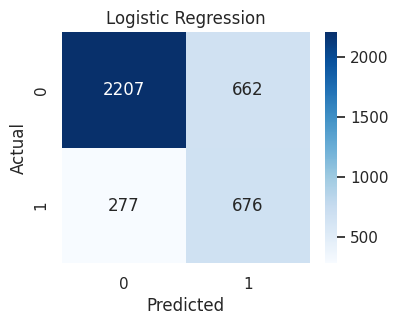

In [39]:
thresh_lr = find_best_threshold(best_lr_model, X_train, y_train, cv_strategy)

metrics_lr, pred_lr = evaluate_model(
    "Logistic Regression", best_lr_model, X_train, y_train, X_test, y_test,
    thresh_lr, save_name='03_confusion_matrix_lr'
)

### Random Forest

,Threshold,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
Model,,,,,,,
Random Forest,0.54,0.6771,0.7988,0.5786,0.7104,0.6378,0.7994


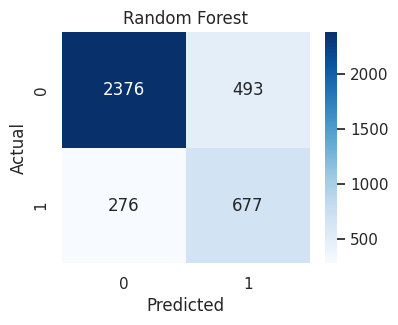

In [40]:
thresh_rf = find_best_threshold(best_rf_model, X_train, y_train, cv_strategy_fast)

metrics_rf, pred_rf = evaluate_model(
    "Random Forest", best_rf_model, X_train, y_train, X_test, y_test,
    thresh_rf, save_name='04_confusion_matrix_rf'
)

## Final Comparison — Both Models

In [41]:
comparison_df = pd.DataFrame([metrics_lr, metrics_rf]).set_index("Model")
print("\n=== MODEL COMPARISON ===")
comparison_df


=== MODEL COMPARISON ===


,Threshold,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
Model,,,,,,,
Logistic Regression,0.54,0.5841,0.7543,0.5052,0.7093,0.5901,0.7825
Random Forest,0.54,0.6771,0.7988,0.5786,0.7104,0.6378,0.7994


# 5. Business Intelligence & Visualization

##1. Recruitment Statistics

In [42]:
total_candidates = len(df)
job_change_count = (df['target'] == 1).sum()
stable_count = (df['target'] == 0).sum()
job_change_rate = (job_change_count / total_candidates) * 100

print(f"Total Candidates Analyzed: {total_candidates}")
print(f"Looking for a Job Change (1): {job_change_count} ({job_change_rate:.2f}%)")
print(f"Not Looking for a Change (0): {stable_count} ({100 - job_change_rate:.2f}%)")

Total Candidates Analyzed: 19109
Looking for a Job Change (1): 4765 (24.94%)
Not Looking for a Change (0): 14344 (75.06%)


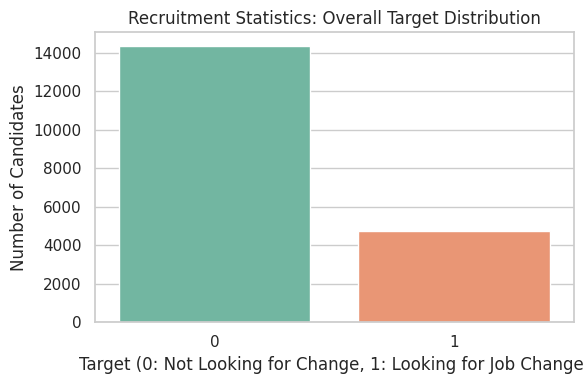

In [43]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', hue='target', palette='Set2', legend=False)
plt.title('Recruitment Statistics: Overall Target Distribution')
plt.xlabel('Target (0: Not Looking for Change, 1: Looking for Job Change)')
plt.ylabel('Number of Candidates')
plt.tight_layout()
save_fig('05_recruitment_statistics')
plt.show()

##2. Candidate Profile Trends

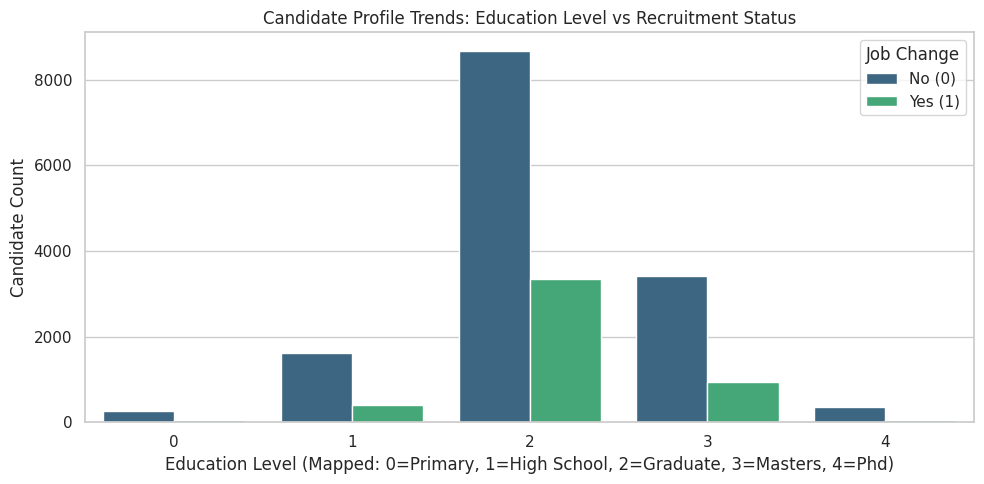

In [44]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='education_level', hue='target', palette='viridis')
plt.title('Candidate Profile Trends: Education Level vs Recruitment Status')
plt.xlabel('Education Level (Mapped: 0=Primary, 1=High School, 2=Graduate, 3=Masters, 4=Phd)')
plt.ylabel('Candidate Count')
plt.legend(title='Job Change', labels=['No (0)', 'Yes (1)'])
plt.tight_layout()
save_fig('06_education_vs_target')
plt.show()

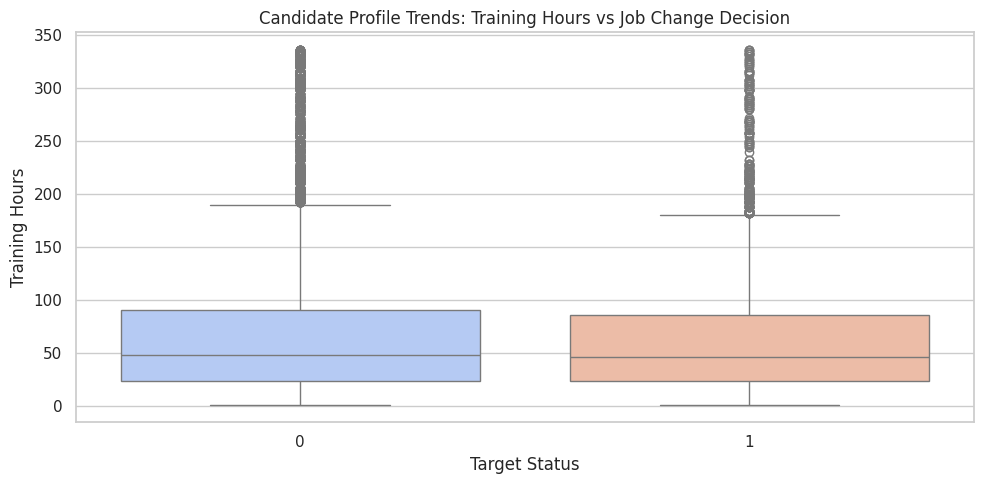

In [45]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='target', y='training_hours', hue='target', palette='coolwarm', legend=False)
plt.title('Candidate Profile Trends: Training Hours vs Job Change Decision')
plt.xlabel('Target Status')
plt.ylabel('Training Hours')
plt.tight_layout()
plt.show()

## 3. Factors influencing job change

In [46]:
feature_names = best_rf_model.named_steps['preprocessing'].get_feature_names_out()
importances = best_rf_model.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df['feature'] = (
    importance_df['feature']
    .str.replace('numerical__', '', regex=False)
    .str.replace('categorical__', '', regex=False)
)
importance_df = importance_df.sort_values(by='importance', ascending=False).head(10)

print("--- Top 5 Factors Influencing Job Change ---")
for idx, row in importance_df.head(5).iterrows():
    print(f"- {row['feature']}: {row['importance']:.4f}")

--- Top 5 Factors Influencing Job Change ---
- city_development_index: 0.3707
- training_hours: 0.1051
- experience: 0.1014
- company_size: 0.0903
- company_size_missing: 0.0476


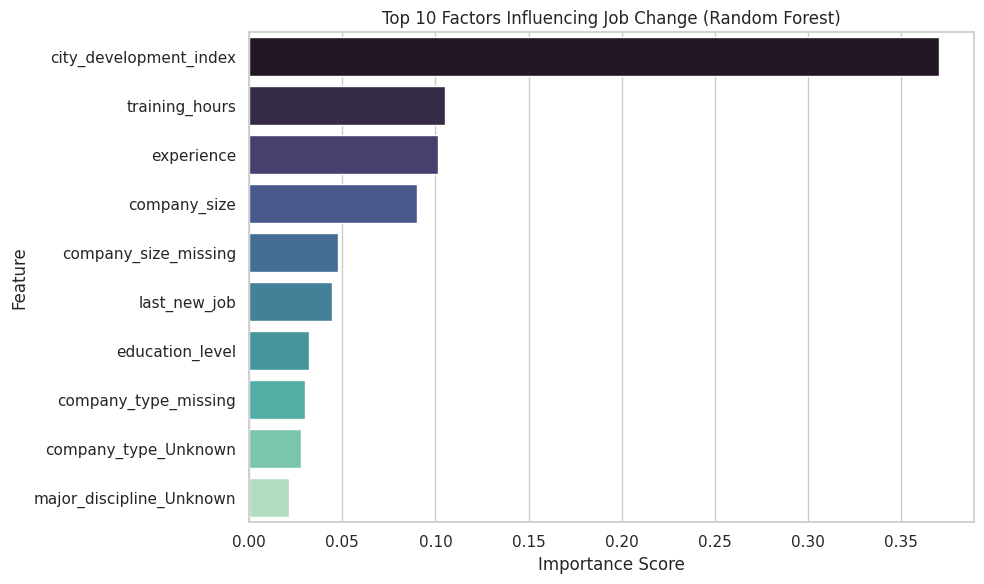

In [47]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', hue='feature', palette='mako', legend=False)
plt.title('Top 10 Factors Influencing Job Change (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
save_fig('07_feature_importance')
plt.show()

# 6. Top Candidates

In [48]:
final_model_name = comparison_df['Test F1'].idxmax()

if final_model_name == 'Random Forest':
    final_model = best_rf_model
    final_threshold = thresh_rf
else:
    final_model = best_lr_model
    final_threshold = thresh_lr

print("Best model selected for ranking:", final_model_name)
print("Test F1 score:", round(comparison_df.loc[final_model_name, 'Test F1'], 4))
print("Threshold used:", round(final_threshold, 2))


Best model selected for ranking: Random Forest
Test F1 score: 0.6378
Threshold used: 0.54


In [49]:
probs = final_model.predict_proba(X_test)[:, 1]

top_candidates = X_test.copy()
top_candidates['probability_to_switch'] = probs
top_candidates['predicted_label'] = (probs >= final_threshold).astype(int)

In [50]:
top_candidates = top_candidates.sort_values('probability_to_switch', ascending=False).head(10)

top_candidates

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,company_size_missing,company_type_missing,probability_to_switch,predicted_label
10670,0.624,Male,1,no_enrollment,2,STEM,5.0,1,Pvt Ltd,0,24,0,0,0.888894,1
13931,0.624,Male,1,no_enrollment,2,STEM,6.0,1,Pvt Ltd,0,22,0,0,0.887887,1
830,0.682,Unknown,0,no_enrollment,2,STEM,2.0,-1,Unknown,1,72,1,1,0.879735,1
3511,0.920,Male,0,no_enrollment,2,STEM,2.0,-1,Unknown,1,34,1,1,0.873930,1
18795,0.624,Unknown,0,no_enrollment,2,STEM,2.0,-1,Unknown,1,50,1,1,0.866434,1
2695,0.550,Male,1,no_enrollment,2,STEM,5.0,1,Public Sector,1,42,0,0,0.865483,1
12808,0.689,Unknown,0,Part time course,2,STEM,2.0,-1,Unknown,1,23,1,1,0.865024,1
2741,0.624,Unknown,1,Full time course,2,STEM,1.0,2,Pvt Ltd,1,7,0,0,0.864187,1
10833,0.920,Male,0,no_enrollment,2,STEM,3.0,-1,Unknown,1,42,1,1,0.862042,1
3387,0.624,Unknown,1,no_enrollment,2,STEM,1.0,4,Pvt Ltd,1,10,0,0,0.861219,1


# 7. Save Outputs

In [51]:
df.to_csv('processed_recruitment_data.csv', index=False)
joblib.dump(final_model, 'smart_recruitment_rf_model.pkl')

print("Saved: processed_recruitment_data.csv, smart_recruitment_rf_model.pkl")
print("Decision threshold to use with the model:", round(final_threshold, 2))

Saved: processed_recruitment_data.csv, smart_recruitment_rf_model.pkl
Decision threshold to use with the model: 0.54
